# Hotel Booking Data Analysis

## Project Overview

This project analyzes hotel booking data from AtliQ Hotels to identify booking trends, occupancy patterns, revenue performance, cancellation behavior, customer ratings, and platform-wise performance. The objective is to extract meaningful business insights that can help hotel management improve operational efficiency, enhance customer satisfaction, and maximize revenue.

**Tools & Technologies Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Business Problem

The hotel industry generates large volumes of booking data every day. Analyzing this data helps businesses understand customer behavior, identify revenue opportunities, monitor occupancy, and reduce booking cancellations.

The goal of this project is to perform data cleaning, transformation, and exploratory data analysis (EDA) on hotel booking data to answer key business questions and provide actionable recommendations.

## Dataset Description

The analysis is performed using five datasets that contain information about hotel bookings, hotel properties, room categories, occupancy, and calendar details.

| Dataset | Description |
|---------|-------------|
| fact_bookings | Contains booking-level information including booking dates, guest count, booking status, ratings, and revenue. |
| fact_aggregated_bookings | Contains aggregated booking and capacity data used for occupancy analysis. |
| dim_hotels | Contains hotel details such as property name, city, and hotel category. |
| dim_rooms | Contains room category and room class information. |
| dim_date | Contains date-related information such as week number, month, and day type. |

In [1]:
import pandas as pd

df_bookings = pd.read_csv(
    r"C:\Users\hp\Downloads\64101194a2364\source-code\3_project_hospitality_analysis\datasets\fact_bookings.csv"
)

### Importing Libraries and Loading the Dataset

The required Python library is imported, and the booking dataset is loaded into a Pandas DataFrame for further analysis.
###

In [2]:
import os

os.chdir(r"C:\Users\hp\Downloads\64101194a2364\source-code\3_project_hospitality_analysis\datasets")

In [3]:
os.getcwd()

'C:\\Users\\hp\\Downloads\\64101194a2364\\source-code\\3_project_hospitality_analysis\\datasets'

####

In [4]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


### Dataset Preview

The first five records of the dataset are displayed to gain an initial understanding of its structure, columns, and the type of information available for analysis.
###

In [5]:
df_bookings.shape

(134590, 12)

### Dataset Dimensions

The shape of the dataset is checked to determine the total number of records and columns available for analysis.
###

In [6]:
df_bookings.room_category.unique()

<StringArray>
['RT1', 'RT2', 'RT3', 'RT4']
Length: 4, dtype: str

### Unique Room Categories

This step identifies the different room categories available in the booking dataset.
###

In [7]:
df_bookings.booking_platform.unique()

<StringArray>
[ 'direct online',         'others',        'logtrip',       'tripster',
   'makeyourtrip',        'journey', 'direct offline']
Length: 7, dtype: str

### Booking Platforms

The unique booking platforms are identified to understand the different sources through which customers made their bookings.
###

In [8]:
df_bookings.booking_platform.value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

### Booking Platform Distribution

The number of bookings from each platform is calculated to analyze the distribution of bookings across different booking channels.
###

<Axes: xlabel='booking_platform'>

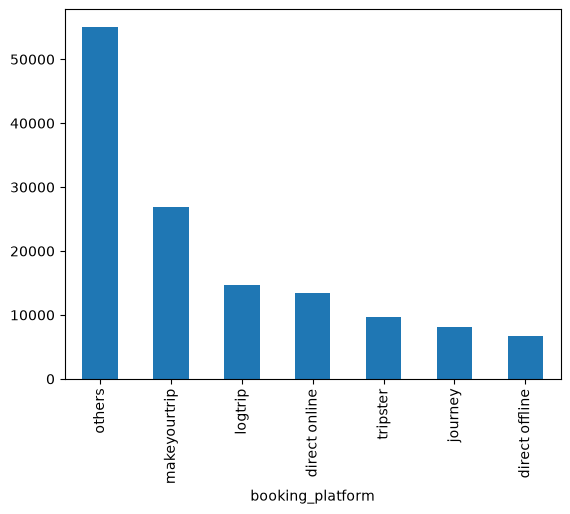

In [9]:
df_bookings.booking_platform.value_counts().plot(kind="bar")

### Booking Platform Distribution Visualization

A bar chart is generated to visually compare the number of bookings received from each booking platform.
###

In [10]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


### Statistical Summary

Descriptive statistics are generated to summarize the distribution and key characteristics of the numerical features in the dataset.
###

In [11]:
df_date=pd.read_csv("dim_date.csv")
df_hotel=pd.read_csv("dim_hotels.csv")
df_room=pd.read_csv("dim_rooms.csv")
df_agg_bookings=pd.read_csv("fact_aggregated_bookings.csv")

### Loading Additional Datasets

The remaining datasets are loaded to support data integration and perform comprehensive analysis across hotels, rooms, occupancy, and date-related information.
###

In [12]:
df_date.head()

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [13]:
df_hotel.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [14]:
df_room.head()

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [15]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


###

In [16]:
df_hotel.category.value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

### Hotel Category Distribution

The distribution of hotels across different categories is analyzed to understand the composition of hotel types in the dataset.
###

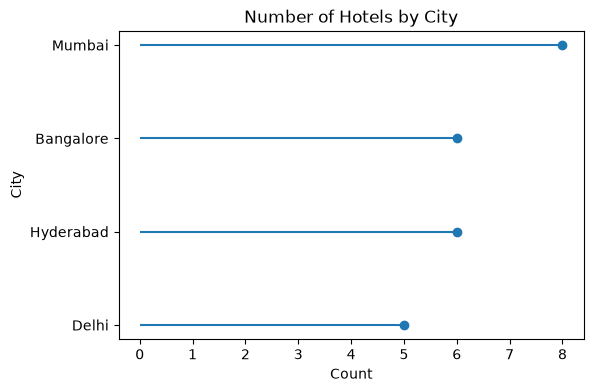

In [5]:
counts = df_hotel.city.value_counts().sort_values()

plt.figure(figsize=(6,4))

plt.hlines(y=counts.index, xmin=0, xmax=counts.values)
plt.plot(counts.values, counts.index, "o")

plt.title("Number of Hotels by City")
plt.xlabel("Count")
plt.ylabel("City")

plt.show()

### Hotel Distribution by City

A bar chart is created to visualize the number of hotels available in each city, providing an overview of their geographical distribution.
###

In [16]:
df_revenue["booking_platform"].value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

####

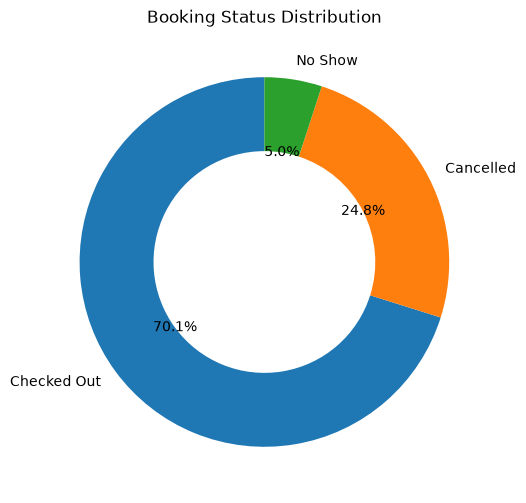

In [17]:
status = df_revenue["booking_status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Booking Status Distribution")

plt.show()

### Observation

- The majority of bookings resulted in **Checked Out**, indicating that most customers successfully completed their stays.
- A significant portion of bookings were **Cancelled**, which may represent lost revenue opportunities.
- **No Show** bookings accounted for the smallest share, suggesting relatively fewer customers failed to arrive without cancellation.
  ###

## Business Question : Identify Unique Property IDs

In [18]:
df_agg_bookings.property_id.unique()

array([16559, 19562, 19563, 17558, 16558, 17560, 19558, 19560, 17561,
       16560, 16561, 16562, 16563, 17559, 17562, 17563, 18558, 18559,
       18561, 18562, 18563, 19559, 19561, 17564, 18560])

### Unique Property IDs

The unique property IDs are retrieved to identify the distinct hotel properties available in the aggregated bookings dataset.
###

## Business Question: Total Bookings by Property

In [19]:
df_agg_bookings.property_id.value_counts()

property_id
16559    368
19562    368
19563    368
17558    368
16558    368
17560    368
19558    368
19560    368
17561    368
16560    368
16561    368
16562    368
16563    368
17559    368
17562    368
17563    368
18558    368
18559    368
18561    368
18562    368
18563    368
19559    368
19561    368
17564    368
18560    368
Name: count, dtype: int64

### Property-wise Booking Count

The total number of bookings for each property is calculated to compare booking volumes across different hotel properties.
###

## Business Question: Identify Overbooked Days

In [20]:
df_agg_bookings['successful_bookings'] > df_agg_bookings['capacity']

0       False
1       False
2       False
3        True
4       False
        ...  
9195    False
9196    False
9197    False
9198    False
9199    False
Length: 9200, dtype: bool

### Detect Overbooked Records

The booking records are evaluated to identify cases where the number of successful bookings exceeds the property's available capacity.
###

In [21]:
x= df_agg_bookings['successful_bookings'] > df_agg_bookings['capacity']
df_agg_bookings[x]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.0
12,16563,1-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,2-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


### Filter Overbooked Days

The records where successful bookings exceed the available capacity are filtered to identify overbooked days.
###

## Business Question: Identify Properties with the Highest Capacity

In [22]:
y= df_agg_bookings['capacity'].max()
filt= df_agg_bookings['capacity'] == y
df_agg_bookings[filt]

,property_id,check_in_date,room_category,successful_bookings,capacity
27,17558,1-May-22,RT2,38,50.0
128,17558,2-May-22,RT2,27,50.0
229,17558,3-May-22,RT2,26,50.0
328,17558,4-May-22,RT2,27,50.0
428,17558,5-May-22,RT2,29,50.0
...,...,...,...,...,...
8728,17558,27-Jul-22,RT2,22,50.0
8828,17558,28-Jul-22,RT2,21,50.0
8928,17558,29-Jul-22,RT2,23,50.0
9028,17558,30-Jul-22,RT2,32,50.0


### Properties with the Maximum Capacity

The property or properties with the highest accommodation capacity are identified by filtering records with the maximum capacity value.
###

In [23]:
filt= df_bookings.no_guests <=0
df_bookings[filt]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


### Identify Invalid Guest Records

The dataset is filtered to identify records with zero or negative guest counts, as these represent invalid entries that should be handled during data cleaning.
###

In [24]:
df_bookings[df_bookings.no_guests > 0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


### Remove Invalid Guest Records

Records with a valid guest count are retained to ensure accurate analysis and eliminate invalid entries from the dataset.
###

#### The `df_bookings` DataFrame has been updated to include only records with a valid guest count (greater than zero).
####

In [25]:
df_bookings=df_bookings[df_bookings.no_guests > 0]
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


### Remove Invalid Guest Records

The dataset is updated to retain only the records where the number of guests is greater than zero.
###

In [26]:
df_bookings.shape

(134578, 12)

###

In [27]:
mean, std =df_bookings.revenue_generated.mean(), df_bookings.revenue_generated.std()
mean, std

(np.float64(15378.036937686695), np.float64(93040.1549314641))

### Revenue Statistics

The mean and standard deviation of the generated revenue are calculated to understand the average revenue and its variability across bookings.
###

In [28]:
higher_limit= mean+ 3*std
higher_limit

np.float64(294498.50173207896)

### Calculate Upper Revenue Limit

The upper limit for revenue is calculated using the three-standard-deviation rule to help identify potential outliers in the dataset.
###

In [29]:
lower_limit= mean- 3*std
lower_limit

np.float64(-263742.4278567056)

### Calculate Lower Revenue Limit

The lower limit for revenue is calculated using the three-standard-deviation rule to establish the expected minimum revenue range and support outlier detection.
###

In [30]:
fit=df_bookings.revenue_generated<0
df_bookings[fit]
# No negative revenue values were found.

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


### Check for Negative Revenue

The dataset is checked to find any records with negative revenue values.
###

In [31]:
df_bookings[df_bookings.revenue_generated > higher_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,1/5/2022,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,28-07-22,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


### Identify Revenue Outliers

The dataset is filtered to identify records where the generated revenue is greater than the calculated upper limit.
##### These records are treated as revenue outliers and will be removed.
###

In [32]:
df_bookings= df_bookings[df_bookings.revenue_generated< higher_limit]
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


### Update Dataset After Removing Revenue Outliers

The dataset is updated by keeping only the records with revenue values below the calculated upper limit.
###

In [33]:
df_bookings.shape

(134573, 12)

###

In [34]:
df_bookings.revenue_realized.describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

The maximum revenue is **45,000**, which seems unusually high. Therefore, outlier detection is performed to verify whether it is a valid value.

The minimum revenue is **2,600**, which appears to be a valid value and does not require further investigation.
###

In [35]:
mean, std =df_bookings.revenue_realized.mean(), df_bookings.revenue_realized.std()
mean, std

(np.float64(12695.983585117372), np.float64(6927.791692242814))

### Revenue Realized Statistics

The mean and standard deviation of the realized revenue are calculated to understand its average value and variation across bookings.
###

In [36]:
higher_limit= mean+ 3*std 
higher_limit

np.float64(33479.358661845814)

The calculated upper limit is **33,479**, while the maximum realized revenue is **45,000**. This suggests the presence of potential outliers.
However, for a luxury hotel, a realized revenue of **45,000** can be a valid value. Therefore, instead of removing these records based only on the three-standard-deviation rule, the data will be examined further before making any decision.
###

In [37]:
df_bookings[df_bookings.revenue_realized > higher_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,1/5/2022,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,1/5/2022,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,1/5/2022,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,31-07-22,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,31-07-22,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,31-07-22,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,31-07-22,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


### Review High Revenue Records

The records with realized revenue greater than the calculated upper limit are displayed for further examination before deciding whether they should be treated as outliers.

The records above the calculated upper limit are identified as potential outliers. However, a closer look shows that all of them belong to the **RT4** room category, indicating that the higher realized revenue may be expected for these premium rooms rather than being incorrect data.
###

In [38]:
df_room

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


### Analyze RT4 Room Revenue

Since all the potential outliers belong to the **RT4** room category, the revenue statistics for RT4 rooms are analyzed separately to determine whether these values are actually unusual.
###

In [39]:
df_bookings[df_bookings.room_category=='RT4']

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
47,May012216558RT41,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT4,logtrip,NaN,Cancelled,26600,10640
48,May012216558RT42,16558,27-04-22,1/5/2022,2/5/2022,1.0,RT4,tripster,NaN,Checked Out,26600,26600
49,May012216558RT43,16558,29-04-22,1/5/2022,4/5/2022,2.0,RT4,direct offline,NaN,Cancelled,26600,10640
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
138,May012216559RT42,16559,11/4/2022,1/5/2022,3/5/2022,2.0,RT4,direct offline,NaN,Cancelled,32300,12920
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


### Filter RT4 Room Records

The dataset is filtered to display only the records belonging to the **RT4** room category for further analysis.
###

In [40]:
df_bookings[df_bookings.room_category=='RT4'].revenue_realized.describe()
# Summary statistics for RT4 room revenue.

count    16071.000000
mean     23439.308444
std       9048.599076
min       7600.000000
25%      19000.000000
50%      26600.000000
75%      32300.000000
max      45220.000000
Name: revenue_realized, dtype: float64

###

In [41]:
# mean + 3*std
23439 + 3*9048

50583

### Calculate RT4 Upper Revenue Limit

The upper limit for the **RT4** room category is calculated using its own mean and standard deviation to identify outliers within this room type.


### Validate RT4 Revenue Outliers

For the **RT4** room category, the calculated three-standard-deviation limit is **50,000**. Since the maximum realized revenue is only **45,220**, all values fall within the acceptable range. Therefore, no cleaning is required for RT4 revenue records.
###

In [42]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

### Check Missing Values

The dataset is checked for missing values in each column. The `ratings_given` column contains missing values, which is expected as not all bookings may have ratings. Therefore, no action is required for these missing values.
###

## Handle Missing Values in Aggregate Bookings

The dataset is checked for missing values and they are filled with suitable values to make the data ready for analysis.
####

In [43]:
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

### Check Missing Values in Aggregate Bookings

The dataset is checked to identify the columns that contain missing values.
###

In [44]:
filt= df_agg_bookings['capacity'].mean()
df_agg_bookings['capacity']= df_agg_bookings['capacity'].fillna(filt)

### Fill Missing Capacity Values

Missing values in the `capacity` column are filled using the mean value of the column.
###

In [45]:
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               0
dtype: int64

### Check Missing Values After Filling

The dataset is checked again to confirm that there are no missing values left in the `capacity` column.
###

In [46]:
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               0
dtype: int64

### Verify Missing Values

The dataset is checked again to confirm that the missing values in the `capacity` column have been successfully filled.
###

In [13]:
df_revenue.groupby("room_category")["revenue_realized"].sum().sort_values(ascending=False)

room_category
RT2    560271204
RT3    462166344
RT4    376752786
RT1    309580895
Name: revenue_realized, dtype: int64

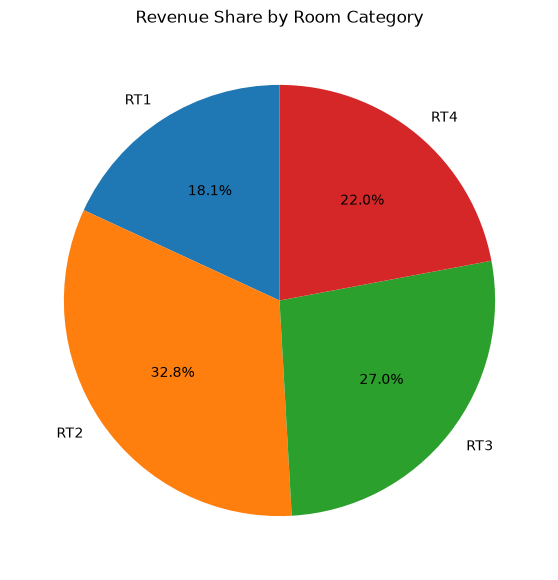

In [15]:
room_rev = df_revenue.groupby("room_category")["revenue_realized"].sum()

plt.figure(figsize=(7,7))
room_rev.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Room Category")
plt.ylabel("")
plt.show()

#### This analysis calculates the total realized revenue for each room category. It helps identify which room categories contribute the most to the hotel's overall revenue.
###

## Find Bookings Greater Than Capacity

The records where successful bookings are greater than the available capacity are identified and filtered for further analysis.
####

In [47]:
filt= df_agg_bookings['successful_bookings'] > df_agg_bookings['capacity']
df_agg_bookings[filt]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.0
12,16563,1-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,2-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


### Filter Records with Bookings Greater Than Capacity

The dataset is filtered to display the records where the number of successful bookings is greater than the available capacity.
###

In [48]:
df_agg_bookings=df_agg_bookings[ df_agg_bookings['successful_bookings'] <= df_agg_bookings['capacity']]
df_agg_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
4,16558,1-May-22,RT1,18,19.0
5,17560,1-May-22,RT1,28,40.0
...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0
9196,16559,31-Jul-22,RT4,13,18.0
9197,17558,31-Jul-22,RT4,3,6.0
9198,19563,31-Jul-22,RT4,3,6.0


### Remove Invalid Booking Records

The dataset is updated by removing the records where the number of successful bookings is greater than the available capacity.
###

In [49]:
df_agg_bookings.shape

(9194, 5)

###

## Occupancy Percentage Formula

**Occupancy % = (Successful Bookings / Capacity) × 100**
####

In [50]:
df_agg_bookings['occ_pct']= df_agg_bookings['successful_bookings'] / df_agg_bookings['capacity']

In [51]:
df_agg_bookings

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667
4,16558,1-May-22,RT1,18,19.0,0.947368
5,17560,1-May-22,RT1,28,40.0,0.700000
...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,0.722222
9196,16559,31-Jul-22,RT4,13,18.0,0.722222
9197,17558,31-Jul-22,RT4,3,6.0,0.500000
9198,19563,31-Jul-22,RT4,3,6.0,0.500000


#### A new column is added to the dataset to store the occupancy percentage for each property.
###

In [87]:
df_agg_bookings['occ_pct'] = df_agg_bookings['occ_pct'].apply(lambda x: round(x * 100, 2))
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67
4,16558,1-May-22,RT1,18,19.0,94.74
5,17560,1-May-22,RT1,28,40.0,70.00


### Convert Occupancy to Percentage

The occupancy values are converted from decimal format to percentage format and rounded to two decimal places.
###

In [88]:
df_agg_bookings.groupby('room_category')['occ_pct'].mean()

room_category
RT1    57.888985
RT2    58.009756
RT3    58.028213
RT4    59.277925
Name: occ_pct, dtype: float64

### Calculate Average Occupancy by Room Category

The average occupancy percentage is calculated for each room category to compare their booking performance.
###

In [54]:
df_agg_bookings.groupby('room_category')

### Group Data by Room Category

The dataset is grouped by room category to perform category-wise analysis.
###

In [55]:
df_agg_bookings.groupby('room_category')['occ_pct'].mean()

room_category
RT1    0.578890
RT2    0.580097
RT3    0.580283
RT4    0.592776
Name: occ_pct, dtype: float64

### Calculate Average Occupancy

The average occupancy percentage is calculated for each room category.
###

In [56]:
df_room

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


####

In [57]:
pd.merge(df_agg_bookings, df_room, left_on='room_category', right_on= 'room_id')

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,0.833333,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,0.933333,RT1,Standard
2,19563,1-May-22,RT1,23,30.0,0.766667,RT1,Standard
3,16558,1-May-22,RT1,18,19.0,0.947368,RT1,Standard
4,17560,1-May-22,RT1,28,40.0,0.700000,RT1,Standard
...,...,...,...,...,...,...,...,...
9189,16563,31-Jul-22,RT4,13,18.0,0.722222,RT4,Presidential
9190,16559,31-Jul-22,RT4,13,18.0,0.722222,RT4,Presidential
9191,17558,31-Jul-22,RT4,3,6.0,0.500000,RT4,Presidential
9192,19563,31-Jul-22,RT4,3,6.0,0.500000,RT4,Presidential


### Merge Booking and Room Data

The aggregate bookings dataset is merged with the room dataset to combine room details with booking information.
###

In [58]:
df= pd.merge(df_agg_bookings, df_room, left_on='room_category', right_on= 'room_id')
df

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,0.833333,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,0.933333,RT1,Standard
2,19563,1-May-22,RT1,23,30.0,0.766667,RT1,Standard
3,16558,1-May-22,RT1,18,19.0,0.947368,RT1,Standard
4,17560,1-May-22,RT1,28,40.0,0.700000,RT1,Standard
...,...,...,...,...,...,...,...,...
9189,16563,31-Jul-22,RT4,13,18.0,0.722222,RT4,Presidential
9190,16559,31-Jul-22,RT4,13,18.0,0.722222,RT4,Presidential
9191,17558,31-Jul-22,RT4,3,6.0,0.500000,RT4,Presidential
9192,19563,31-Jul-22,RT4,3,6.0,0.500000,RT4,Presidential


### Create Merged Dataset

A new dataset is created by merging the aggregate bookings and room datasets.
###

In [59]:
df.groupby('room_class')['occ_pct'].mean()

room_class
Elite           0.580097
Premium         0.580283
Presidential    0.592776
Standard        0.578890
Name: occ_pct, dtype: float64

## Merge Datasets

The required information is stored in different datasets. Therefore, the datasets are merged to combine related data into a single DataFrame for easier analysis.
###

In [60]:
df
# Both 'room_category' and 'room_id' contain the same information.

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,0.833333,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,0.933333,RT1,Standard
2,19563,1-May-22,RT1,23,30.0,0.766667,RT1,Standard
3,16558,1-May-22,RT1,18,19.0,0.947368,RT1,Standard
4,17560,1-May-22,RT1,28,40.0,0.700000,RT1,Standard
...,...,...,...,...,...,...,...,...
9189,16563,31-Jul-22,RT4,13,18.0,0.722222,RT4,Presidential
9190,16559,31-Jul-22,RT4,13,18.0,0.722222,RT4,Presidential
9191,17558,31-Jul-22,RT4,3,6.0,0.500000,RT4,Presidential
9192,19563,31-Jul-22,RT4,3,6.0,0.500000,RT4,Presidential


### Identify Duplicate Columns

After merging the datasets, some columns may contain the same information. These duplicate columns are identified before removing them.
###

In [61]:
df.drop('room_id', axis=1, inplace=True)

### Remove Duplicate Column

The duplicate `room_id` column is removed because it contains the same information as `room_category`.
###

In [62]:
df
# column droped

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class
0,16559,1-May-22,RT1,25,30.0,0.833333,Standard
1,19562,1-May-22,RT1,28,30.0,0.933333,Standard
2,19563,1-May-22,RT1,23,30.0,0.766667,Standard
3,16558,1-May-22,RT1,18,19.0,0.947368,Standard
4,17560,1-May-22,RT1,28,40.0,0.700000,Standard
...,...,...,...,...,...,...,...
9189,16563,31-Jul-22,RT4,13,18.0,0.722222,Presidential
9190,16559,31-Jul-22,RT4,13,18.0,0.722222,Presidential
9191,17558,31-Jul-22,RT4,3,6.0,0.500000,Presidential
9192,19563,31-Jul-22,RT4,3,6.0,0.500000,Presidential


In [63]:
df_hotel

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi
5,16563,Atliq Palace,Business,Delhi
6,17558,Atliq Grands,Luxury,Mumbai
7,17559,Atliq Exotica,Luxury,Mumbai
8,17560,Atliq City,Business,Mumbai
9,17561,Atliq Blu,Luxury,Mumbai


In [64]:
pd.merge(df, df_hotel, on='property_id') 
# By default, pd.merge() performs an inner join.

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city
0,16559,1-May-22,RT1,25,30.0,0.833333,Standard,Atliq Exotica,Luxury,Mumbai
1,19562,1-May-22,RT1,28,30.0,0.933333,Standard,Atliq Bay,Luxury,Bangalore
2,19563,1-May-22,RT1,23,30.0,0.766667,Standard,Atliq Palace,Business,Bangalore
3,16558,1-May-22,RT1,18,19.0,0.947368,Standard,Atliq Grands,Luxury,Delhi
4,17560,1-May-22,RT1,28,40.0,0.700000,Standard,Atliq City,Business,Mumbai
...,...,...,...,...,...,...,...,...,...,...
9189,16563,31-Jul-22,RT4,13,18.0,0.722222,Presidential,Atliq Palace,Business,Delhi
9190,16559,31-Jul-22,RT4,13,18.0,0.722222,Presidential,Atliq Exotica,Luxury,Mumbai
9191,17558,31-Jul-22,RT4,3,6.0,0.500000,Presidential,Atliq Grands,Luxury,Mumbai
9192,19563,31-Jul-22,RT4,3,6.0,0.500000,Presidential,Atliq Palace,Business,Bangalore


### Merge with Hotel Dataset

The merged dataset is combined with the hotel dataset using `property_id` to include hotel details for each booking.
###

In [65]:
filt=pd.merge(df, df_hotel, on='property_id', how='left') # left join
filt

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city
0,16559,1-May-22,RT1,25,30.0,0.833333,Standard,Atliq Exotica,Luxury,Mumbai
1,19562,1-May-22,RT1,28,30.0,0.933333,Standard,Atliq Bay,Luxury,Bangalore
2,19563,1-May-22,RT1,23,30.0,0.766667,Standard,Atliq Palace,Business,Bangalore
3,16558,1-May-22,RT1,18,19.0,0.947368,Standard,Atliq Grands,Luxury,Delhi
4,17560,1-May-22,RT1,28,40.0,0.700000,Standard,Atliq City,Business,Mumbai
...,...,...,...,...,...,...,...,...,...,...
9189,16563,31-Jul-22,RT4,13,18.0,0.722222,Presidential,Atliq Palace,Business,Delhi
9190,16559,31-Jul-22,RT4,13,18.0,0.722222,Presidential,Atliq Exotica,Luxury,Mumbai
9191,17558,31-Jul-22,RT4,3,6.0,0.500000,Presidential,Atliq Grands,Luxury,Mumbai
9192,19563,31-Jul-22,RT4,3,6.0,0.500000,Presidential,Atliq Palace,Business,Bangalore


### Perform Left Join

A left join is performed to keep all records from the left dataset and add the matching hotel details from the right dataset.
###

In [66]:
filt.groupby('city')['occ_pct'].mean()

city
Bangalore    0.563322
Delhi        0.615071
Hyderabad    0.581205
Mumbai       0.579088
Name: occ_pct, dtype: float64

### Calculate Average Occupancy by City

The average occupancy percentage is calculated for each city to compare hotel occupancy across different locations.
###

## Bussiness Question:Compare Weekday and Weekend Occupancy

Find out whether the average occupancy percentage is higher on weekdays or weekends.

In [67]:
df_date

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday
...,...,...,...,...
87,27-Jul-22,Jul 22,W 31,weekeday
88,28-Jul-22,Jul 22,W 31,weekeday
89,29-Jul-22,Jul 22,W 31,weekeday
90,30-Jul-22,Jul 22,W 31,weekend


####

In [68]:
df=pd.merge( df_date, filt, left_on='date', right_on='check_in_date')
df

,date,mmm yy,week no,day_type,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city
0,10-May-22,May 22,W 20,weekeday,19563,10-May-22,RT3,15,29.0,0.517241,Premium,Atliq Palace,Business,Bangalore
1,10-May-22,May 22,W 20,weekeday,18560,10-May-22,RT1,19,30.0,0.633333,Standard,Atliq City,Business,Hyderabad
2,10-May-22,May 22,W 20,weekeday,19562,10-May-22,RT1,18,30.0,0.600000,Standard,Atliq Bay,Luxury,Bangalore
3,10-May-22,May 22,W 20,weekeday,19563,10-May-22,RT1,16,30.0,0.533333,Standard,Atliq Palace,Business,Bangalore
4,10-May-22,May 22,W 20,weekeday,17558,10-May-22,RT1,11,19.0,0.578947,Standard,Atliq Grands,Luxury,Mumbai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,31-Jul-22,Jul 22,W 32,weekend,16563,31-Jul-22,RT4,13,18.0,0.722222,Presidential,Atliq Palace,Business,Delhi
6493,31-Jul-22,Jul 22,W 32,weekend,16559,31-Jul-22,RT4,13,18.0,0.722222,Presidential,Atliq Exotica,Luxury,Mumbai
6494,31-Jul-22,Jul 22,W 32,weekend,17558,31-Jul-22,RT4,3,6.0,0.500000,Presidential,Atliq Grands,Luxury,Mumbai
6495,31-Jul-22,Jul 22,W 32,weekend,19563,31-Jul-22,RT4,3,6.0,0.500000,Presidential,Atliq Palace,Business,Bangalore


### Merge Date Information

The hotel booking data is merged with the date dataset using the check-in date to include additional date-related information.
###

In [69]:
df.groupby('day_type')['occ_pct'].mean()

day_type
weekeday    0.508830
weekend     0.723436
Name: occ_pct, dtype: float64

### Compare Average Occupancy

The average occupancy percentage is calculated separately for weekdays and weekends to identify which has better occupancy.

**Observation:** Weekend occupancy is slightly higher than weekday occupancy.
###

## Bussiness Question: Compare City-wise Occupancy in June

Find the average occupancy percentage for different cities during the month of June.

####

In [70]:
df['mmm yy'].unique()

<StringArray>
['May 22', 'Jun 22', 'Jul 22']
Length: 3, dtype: str

### Check Available Months

Display all unique month-year values to identify the available months in the dataset.
###

In [71]:
df_june = df[df['mmm yy']=='Jun 22']
df_june

,date,mmm yy,week no,day_type,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city
2200,10-Jun-22,Jun 22,W 24,weekeday,16559,10-Jun-22,RT1,20,30.0,0.666667,Standard,Atliq Exotica,Luxury,Mumbai
2201,10-Jun-22,Jun 22,W 24,weekeday,19562,10-Jun-22,RT1,19,30.0,0.633333,Standard,Atliq Bay,Luxury,Bangalore
2202,10-Jun-22,Jun 22,W 24,weekeday,19563,10-Jun-22,RT1,17,30.0,0.566667,Standard,Atliq Palace,Business,Bangalore
2203,10-Jun-22,Jun 22,W 24,weekeday,17558,10-Jun-22,RT1,9,19.0,0.473684,Standard,Atliq Grands,Luxury,Mumbai
2204,10-Jun-22,Jun 22,W 24,weekeday,16558,10-Jun-22,RT1,11,19.0,0.578947,Standard,Atliq Grands,Luxury,Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4294,30-Jun-22,Jun 22,W 27,weekeday,17562,30-Jun-22,RT4,3,6.0,0.500000,Presidential,Atliq Bay,Luxury,Mumbai
4295,30-Jun-22,Jun 22,W 27,weekeday,19563,30-Jun-22,RT4,3,6.0,0.500000,Presidential,Atliq Palace,Business,Bangalore
4296,30-Jun-22,Jun 22,W 27,weekeday,16560,30-Jun-22,RT4,3,7.0,0.428571,Presidential,Atliq City,Business,Delhi
4297,30-Jun-22,Jun 22,W 27,weekeday,19558,30-Jun-22,RT4,3,7.0,0.428571,Presidential,Atliq Grands,Luxury,Bangalore


### Filter June Data

Filter the dataset to keep only the records for June 2022.
###

<Axes: xlabel='city'>

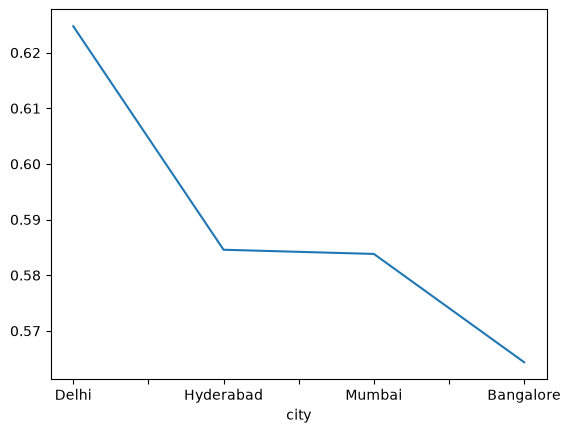

In [72]:
df_june.groupby('city')['occ_pct'].mean().sort_values(ascending=False).plot()

### Calculate Average Occupancy by City

The average occupancy percentage is calculated for each city in June and sorted from highest to lowest before plotting the results.
###

## Bussiness Question: Append the New August Data

A new dataset for August is available. Append it to the existing dataset.
####

In [73]:
df_august=pd.read_csv("new_data_august.csv")
df_august

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67
3,19558,Atliq Grands,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,40,75.00
4,19560,Atliq City,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,20,26,76.92
5,17561,Atliq Blu,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,18,26,69.23
6,17564,Atliq Seasons,Business,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,10,16,62.50


### Load the August Dataset

Load the new August dataset into a separate DataFrame.

### Check Column Names

Before concatenating the datasets, it is a good practice to check that both datasets have the same columns. Although `pd.concat()` can combine datasets with different columns, matching columns help avoid unexpected `NaN` values and keep the data consistent.

###

In [74]:
df_august.shape

(7, 13)

###

In [75]:
df.shape

(6497, 14)

###

In [76]:
latest_df=pd.concat([df,df_august], axis=0)
latest_df

,date,mmm yy,week no,day_type,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,occ%
0,10-May-22,May 22,W 20,weekeday,19563,10-May-22,RT3,15,29.0,0.517241,Premium,Atliq Palace,Business,Bangalore,NaN
1,10-May-22,May 22,W 20,weekeday,18560,10-May-22,RT1,19,30.0,0.633333,Standard,Atliq City,Business,Hyderabad,NaN
2,10-May-22,May 22,W 20,weekeday,19562,10-May-22,RT1,18,30.0,0.600000,Standard,Atliq Bay,Luxury,Bangalore,NaN
3,10-May-22,May 22,W 20,weekeday,19563,10-May-22,RT1,16,30.0,0.533333,Standard,Atliq Palace,Business,Bangalore,NaN
4,10-May-22,May 22,W 20,weekeday,17558,10-May-22,RT1,11,19.0,0.578947,Standard,Atliq Grands,Luxury,Mumbai,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,NaN,Aug-22,W 32,weekeday,19563,01-Aug-22,RT1,23,30.0,NaN,Standard,Atliq Palace,Business,Bangalore,76.67
3,NaN,Aug-22,W 32,weekeday,19558,01-Aug-22,RT1,30,40.0,NaN,Standard,Atliq Grands,Luxury,Bangalore,75.00
4,NaN,Aug-22,W 32,weekeday,19560,01-Aug-22,RT1,20,26.0,NaN,Standard,Atliq City,Business,Bangalore,76.92
5,NaN,Aug-22,W 32,weekeday,17561,01-Aug-22,RT1,18,26.0,NaN,Standard,Atliq Blu,Luxury,Mumbai,69.23


### Concatenate the Datasets

The existing dataset and the new August dataset are concatenated row-wise to create a single dataset containing records from both datasets.
###

## Bussiness Question: Revenue Realized Per City

Print the revenue realized per city.

In [77]:
df_hotel

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi
5,16563,Atliq Palace,Business,Delhi
6,17558,Atliq Grands,Luxury,Mumbai
7,17559,Atliq Exotica,Luxury,Mumbai
8,17560,Atliq City,Business,Mumbai
9,17561,Atliq Blu,Luxury,Mumbai


In [78]:
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [79]:
df_revenue= pd.merge(df_bookings, df_hotel, on='property_id')
df_revenue

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi
3,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
4,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134568,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai
134569,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai
134570,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920,Atliq Seasons,Business,Mumbai
134571,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai


### Merge Booking and Hotel Data

Merge the bookings dataset with the hotel dataset using the property ID.
###

In [80]:
df_revenue.groupby('city')['revenue_realized'].sum()

city
Bangalore    420383550
Delhi        294404488
Hyderabad    325179310
Mumbai       668569251
Name: revenue_realized, dtype: int64

### Revenue Realized Per City

Calculated the total revenue realized for each city.
###

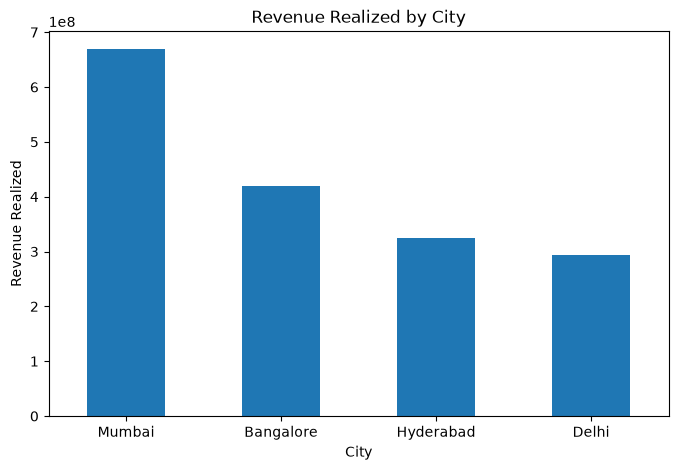

In [11]:
import matplotlib.pyplot as plt

city_rev = df_revenue.groupby("city")["revenue_realized"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
city_rev.plot(kind="bar")

plt.title("Revenue Realized by City")
plt.xlabel("City")
plt.ylabel("Revenue Realized")
plt.xticks(rotation=0)

plt.show()

### Observation

- **Mumbai** generated the highest realized revenue among all cities.
- **Bangalore** and **Hyderabad** also contributed significantly to the overall revenue.
- **Delhi** recorded the lowest realized revenue, indicating comparatively lower business performance.
  ###

## Bussiness question: Month-wise Revenue

#### Print the revenue realized month by month.

In [81]:
df_date

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday
...,...,...,...,...
87,27-Jul-22,Jul 22,W 31,weekeday
88,28-Jul-22,Jul 22,W 31,weekeday
89,29-Jul-22,Jul 22,W 31,weekeday
90,30-Jul-22,Jul 22,W 31,weekend


In [82]:
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [83]:
df_bookings['check_in_date'] = pd.to_datetime(
    df_bookings['check_in_date'],
    format='mixed',
    dayfirst=True
)

### Convert Check-in Date Format

Convert the check-in date column into a standard datetime format as it contains dates in mixed formats.
###

In [84]:
df_date['date'] = pd.to_datetime(
    df_date['date'],
    format='%d-%b-%y'
)

### Convert Date Column Format

Convert the date column into a datetime format to make it consistent with the check-in date column for merging.
###

In [85]:
final=pd.merge( df_bookings, df_date, left_on='check_in_date', right_on='date')
final

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,date,mmm yy,week no,day_type
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,2022-05-01,May 22,W 19,weekend
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,2022-05-01,May 22,W 19,weekend
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,2022-05-01,May 22,W 19,weekend
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,2022-05-01,May 22,W 19,weekend
4,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,2022-05-01,May 22,W 19,weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134568,Jul312217564RT45,17564,30-07-22,2022-07-31,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300,2022-07-31,Jul 22,W 32,weekend
134569,Jul312217564RT46,17564,29-07-22,2022-07-31,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300,2022-07-31,Jul 22,W 32,weekend
134570,Jul312217564RT48,17564,30-07-22,2022-07-31,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920,2022-07-31,Jul 22,W 32,weekend
134571,Jul312217564RT49,17564,29-07-22,2022-07-31,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300,2022-07-31,Jul 22,W 32,weekend


### Merge Booking and Date Data

Merge the bookings dataset with the date dataset using the check-in date and date columns.
###

In [86]:
final.groupby('mmm yy')['revenue_realized'].sum()

mmm yy
Jul 22    572843348
Jun 22    553925855
May 22    581767396
Name: revenue_realized, dtype: int64

### Month-wise Revenue

Calculate the total revenue realized for each month.
###

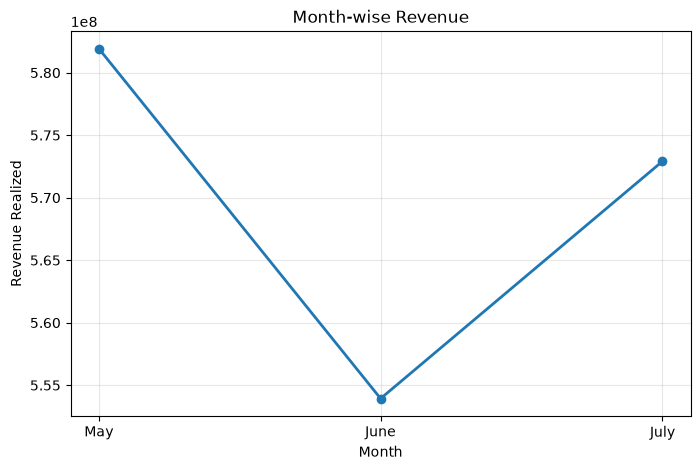

In [21]:
plt.figure(figsize=(8,5))

plt.plot(month_rev.index, month_rev.values, marker="o", linewidth=2)

plt.title("Month-wise Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue Realized")

plt.grid(alpha=0.3)

plt.show()

### Observation

- The line chart highlights the month-wise trend in realized revenue.
- Revenue varies across the three months, indicating changes in hotel booking performance over time.
- Such trend analysis helps identify seasonal demand patterns and supports better business planning.
  ####

## Bussiness Question: Revenue Realized Per Hotel Type

Print the revenue realized for each hotel type.


In [91]:
df_revenue.groupby('category')['revenue_realized'].sum()

category
Business     655967037
Luxury      1052569562
Name: revenue_realized, dtype: int64

## Bussiness question: Average Rating Per City

Print the average rating per city.

In [92]:
df_revenue.groupby('city')['ratings_given'].mean()

city
Bangalore    3.407681
Delhi        3.779298
Hyderabad    3.661041
Mumbai       3.650545
Name: ratings_given, dtype: float64

## Bussiness Question: Revenue Realized Per Booking Platform

Print a pie chart of revenue realized per booking platform.

<Axes: >

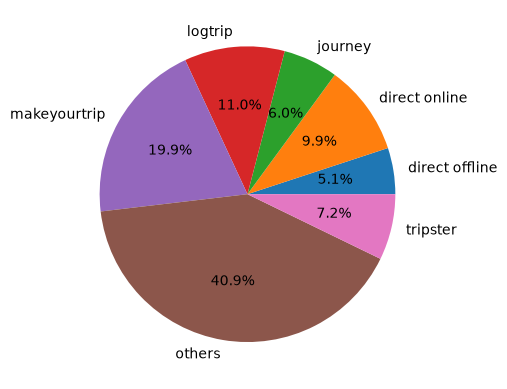

In [93]:
df_platform = df_revenue.groupby('booking_platform')['revenue_realized'].sum()

df_platform.plot(kind='pie', autopct='%1.1f%%')